# Parte V: Exploración y Visualización de Datos Avanzada

En esta quinta parte del proyecto, vamos a expandir nuestro análisis exploratorio de datos (EDA) y visualización utilizando técnicas avanzadas. Aplicaremos todo lo que hemos aprendido hasta ahora, incluyendo cuadrículas, leyendas, anotaciones, flechas, y subplots, para obtener una comprensión más profunda de nuestro conjunto de datos de ventas.


## Continuar desde la Parte IV
Asegúrate de tener el DataFrame df ya cargado y preparado desde la Parte IV.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("../data/retail_sales_dataset.csv")

#cambiar columna date a datetime
df['Date'] = pd.to_datetime(df['Date'])
# Extraer el mes de la columna Date y crear una nueva columna
df['Mes'] = df['Date'].dt.month
# Crear una nueva columna con el nombre completo del mes
df['nombreMes'] = df['Date'].dt.month_name()

#Normalizacion de Datos
def NormalizCol(columna):
    valores_min = columna.min()
    valores_max = columna.max()
    return (columna - valores_min) / (valores_max - valores_min)

# Aplicarlo la normalizacion a la columna 'total'
df['NormTotalAmount'] = NormalizCol(df['Total Amount'])

#creando variable categorica como Tipo de Venta, si la venta fue Baja, Media o Alta
df['TipoVenta'] = pd.qcut(df['Total Amount'], q=3, labels=['Baja', 'Media', 'Alta'])

#Calcula la desviación de cada venta respecto a la media de su grupo.
#se calcula el promedio por categoria alta, media, baja
promedios = df.groupby('TipoVenta')['Total Amount'].mean()

#creamos funcion para calcular desviacion
#idea salio desde: https://blog.finxter.com/calculating-mean-absolute-deviation-in-dataframe-rows-and-columns-using-python/
#manteniendo la solicitud que fuese usando apply
def desviacion(fila):
    return fila['Total Amount'] - promedios[fila['TipoVenta']]

#Se crea nueva columna aplicando la funcion anterior
df['Desviacion'] = df.apply(desviacion, axis=1)

C:\Users\jr_ca\AppData\Local\Temp\ipykernel_7032\2059028715.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  promedios = df.groupby('TipoVenta')['Total Amount'].mean()


In [2]:
df.sample(8)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Mes,nombreMes,NormTotalAmount,TipoVenta,Desviacion
215,216,2023-07-11,CUST216,Male,62,Electronics,2,50,100,7,July,0.037975,Media,-110.113636
330,331,2023-02-11,CUST331,Male,28,Electronics,3,30,90,2,February,0.032911,Baja,37.163324
278,279,2023-08-05,CUST279,Male,50,Clothing,1,500,500,8,August,0.240506,Media,289.886364
777,778,2023-11-18,CUST778,Female,47,Beauty,4,25,100,11,November,0.037975,Media,-110.113636
377,378,2023-06-28,CUST378,Male,50,Beauty,1,300,300,6,June,0.139241,Media,89.886364
824,825,2023-08-26,CUST825,Female,46,Beauty,1,25,25,8,August,0.000000,Baja,-27.836676
143,144,2023-07-15,CUST144,Female,59,Beauty,3,500,1500,7,July,0.746835,Alta,283.946488
573,574,2023-08-31,CUST574,Female,63,Electronics,2,25,50,8,August,0.012658,Baja,-2.836676



## Exploración de Datos Avanzada
* Realiza un análisis de correlación y crea un mapa de calor para visualizar las relaciones entre las variables.
* Crea subplots para comparar diferentes variables clave.
* Añade cuadrículas, leyendas, anotaciones y flechas a tus gráficos para mejorar la claridad y la información.

Text(0.5, 1.0, 'Matriz de Correlación')

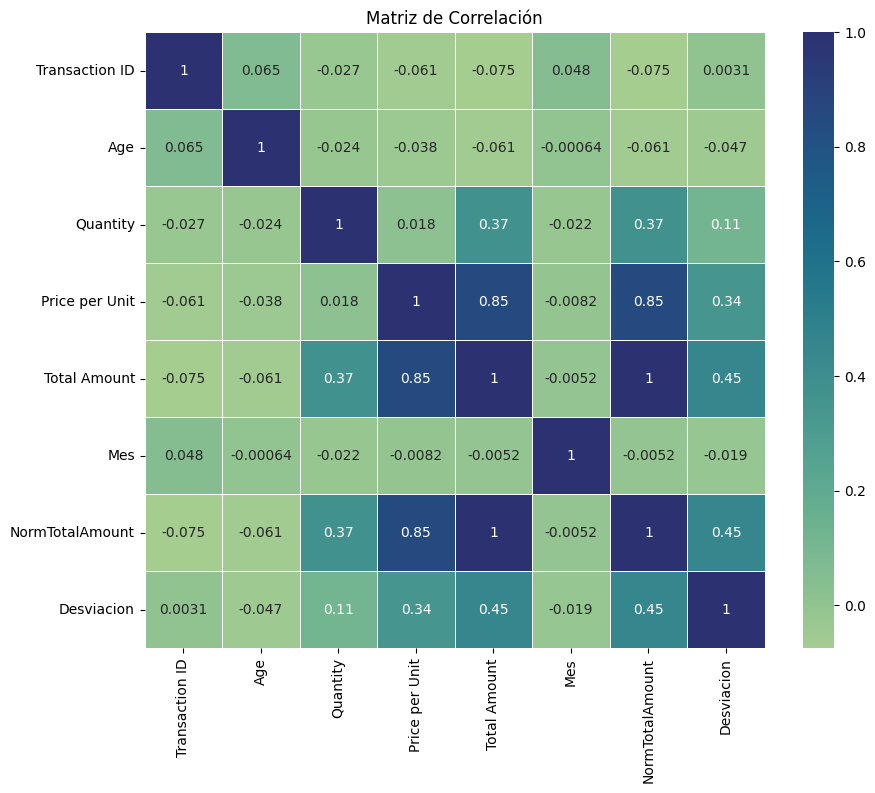

In [3]:
#ESTA MATRIZ DE CORRELACION SE HIZO EN EL EJERCICIO ANTERIOR, PERO NO SE OBSERVA MUCHAS CORRELACIONES ENTRE LAS VARIABLES NUMERICAS
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='crest', linewidths=0.5)
plt.title('Matriz de Correlación')

In [4]:
#VAMOS A CREAR SUBSETS DEL DATAFRAME PRINCIPAL PARA VER SI LOGRAMOS OBSERVAR OTRAS CORRELACIONES OCULTAS INICIALMENTE
Clothing = df[df['Product Category'] == 'Clothing']
Beauty = df[df['Product Category'] == 'Beauty']
Electronics = df[df['Product Category'] == 'Electronics']

Baja = df[df['TipoVenta'] == 'Baja']
Media = df[df['TipoVenta'] == 'Media']
Alta = df[df['TipoVenta'] == 'Alta']

Male = df[df['Gender'] == 'Male']
Female = df[df['Gender'] == 'Female']


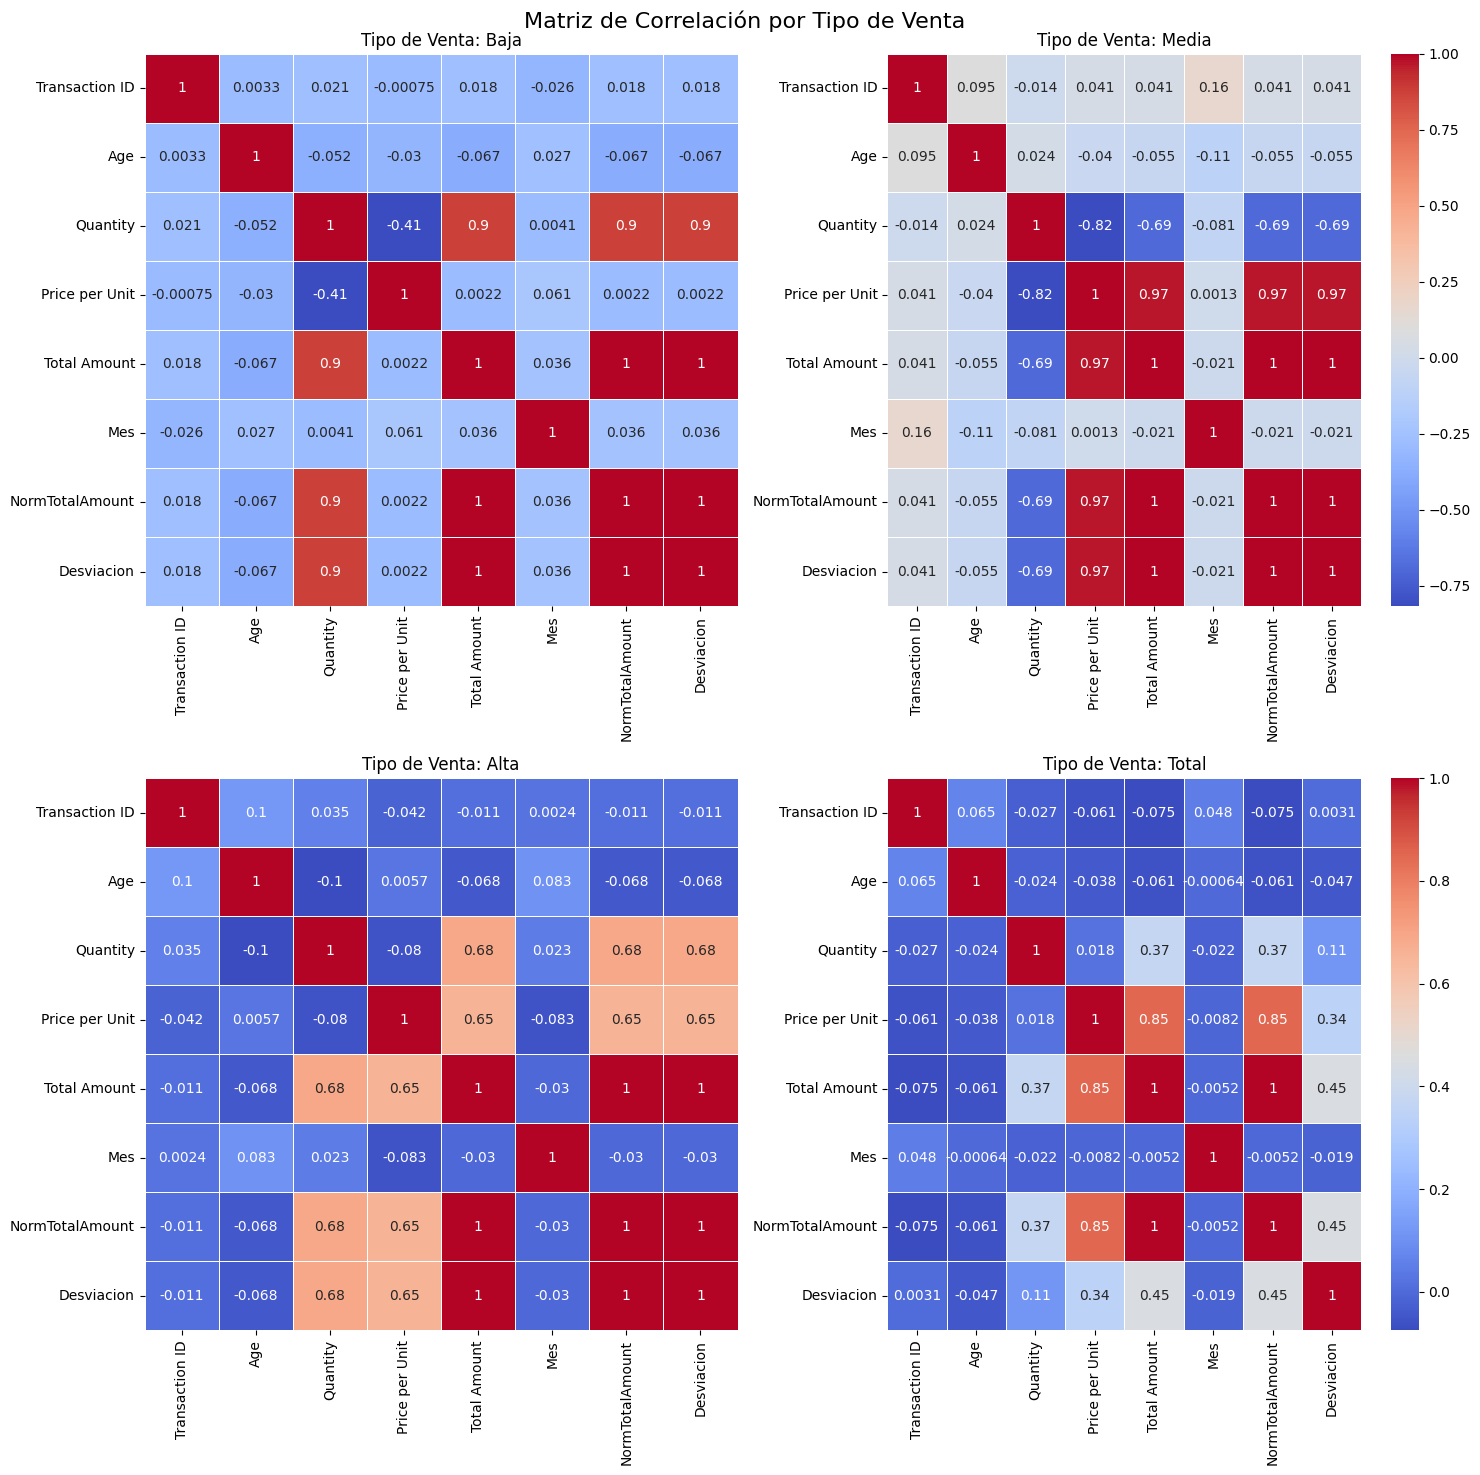

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
fig.suptitle('Matriz de Correlación por Tipo de Venta', fontsize=16)

sns.heatmap(Baja.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5, ax=axes[0,0], cbar=False)
sns.heatmap(Media.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5, ax=axes[0,1])
sns.heatmap(Alta.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5, ax=axes[1,0], cbar=False)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5, ax=axes[1,1])
axes[0,0].set_title('Tipo de Venta: Baja')
axes[0,1].set_title('Tipo de Venta: Media')
axes[1,0].set_title('Tipo de Venta: Alta')
axes[1,1].set_title('Tipo de Venta: Total')



plt.tight_layout()
plt.show()

---
* Si bien las correlaciones se ven similares en los 4 casos, se observa una diferencia
* La relacion Quantity - Price per Unit es diferente en el tipo de venta Media. Tiene una correlacion negativa a diferencia de las otras categorias
* Ploteamos esas correlaciones entre esas 3 categorias.
---

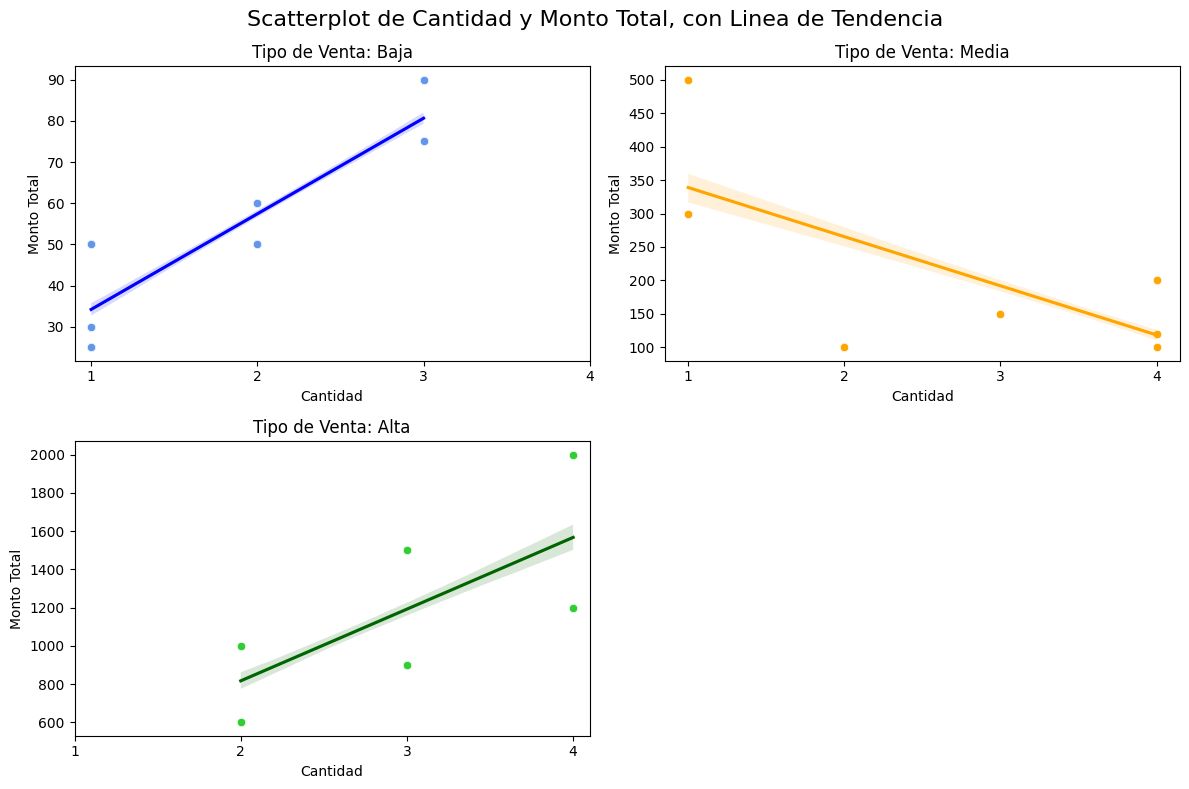

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
fig.suptitle('Scatterplot de Cantidad y Monto Total, con Linea de Tendencia', fontsize=16)

sns.scatterplot(data=Baja, x='Quantity', y='Total Amount', color='cornflowerblue', ax=axes[0,0])
sns.scatterplot(data=Media, x='Quantity', y='Total Amount', color='orange',ax=axes[0,1])
sns.scatterplot(data=Alta, x='Quantity', y='Total Amount', color='limegreen',ax=axes[1,0])

sns.regplot(data=Baja, x='Quantity', y='Total Amount', scatter=False, label='Baja', color='blue', ax=axes[0,0])
sns.regplot(data=Media, x='Quantity', y='Total Amount', scatter=False, label='Media', color='orange', ax=axes[0,1])
sns.regplot(data=Alta, x='Quantity', y='Total Amount', scatter=False, label='Alta', color='darkgreen', ax=axes[1,0])

axes[0, 0].set(title="Tipo de Venta: Baja", xlabel="Cantidad", ylabel="Monto Total", xticks=[1,2,3,4])
axes[0, 1].set(title="Tipo de Venta: Media", xlabel="Cantidad", ylabel="Monto Total", xticks=[1,2,3,4])
axes[1, 0].set(title="Tipo de Venta: Alta", xlabel="Cantidad", ylabel="Monto Total", xticks=[1,2,3,4])
axes[1,1].remove()


plt.tight_layout()
plt.show()

---
* Existe fuerte correlacion positiva en tipo de venta baja y alta
* En tipo de venta media, la correlacion entre cantidad de items comprados y monto total es negativo
* Esto puede explicarse porque al presentar precios mas altos, las personas son mas planificadoras o cuidadosas en adquirir esos nuevos insumos.

---

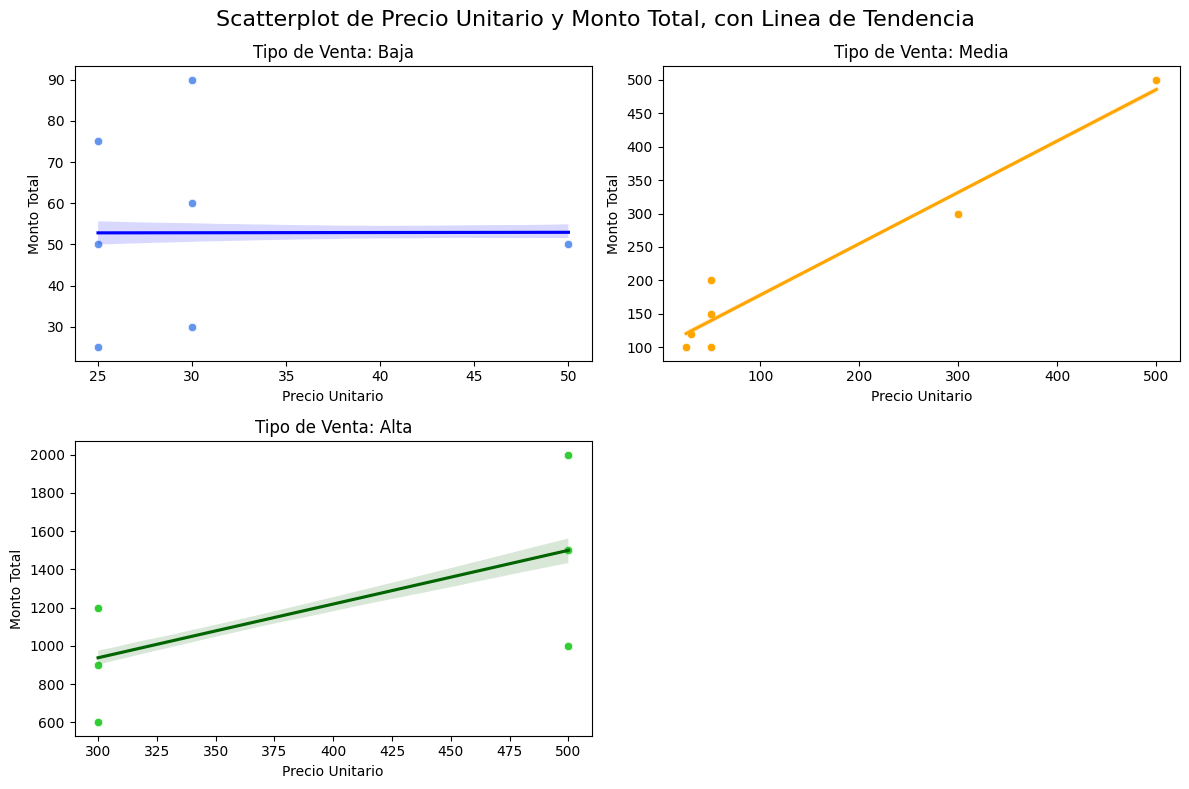

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
fig.suptitle('Scatterplot de Precio Unitario y Monto Total, con Linea de Tendencia', fontsize=16)

sns.scatterplot(data=Baja, x='Price per Unit', y='Total Amount', color='cornflowerblue', ax=axes[0,0])
sns.scatterplot(data=Media, x='Price per Unit', y='Total Amount', color='orange',ax=axes[0,1])
sns.scatterplot(data=Alta, x='Price per Unit', y='Total Amount', color='limegreen',ax=axes[1,0])

sns.regplot(data=Baja, x='Price per Unit', y='Total Amount', scatter=False, label='Baja', color='blue', ax=axes[0,0])
sns.regplot(data=Media, x='Price per Unit', y='Total Amount', scatter=False, label='Media', color='orange', ax=axes[0,1])
sns.regplot(data=Alta, x='Price per Unit', y='Total Amount', scatter=False, label='Alta', color='darkgreen', ax=axes[1,0])

axes[0, 0].set(title="Tipo de Venta: Baja", xlabel="Precio Unitario", ylabel="Monto Total")
axes[0, 1].set(title="Tipo de Venta: Media", xlabel="Precio Unitario", ylabel="Monto Total")
axes[1, 0].set(title="Tipo de Venta: Alta", xlabel="Precio Unitario", ylabel="Monto Total")
axes[1,1].remove()


plt.tight_layout()
plt.show()

---
* Cuando revisamos como afecta el precio unitario al total de la compra vemos cosas diferentes
* En Compra “Media” tiene alta correlación positiva, dando indicios que las compras a precios mayores son mas planificadas, mientras las compras menores sueles ser mas libres.
* Se observa una correlación casi plana en Ventas Bajas
* Y se observa una leve correlación positiva en Venta Alta. 


---

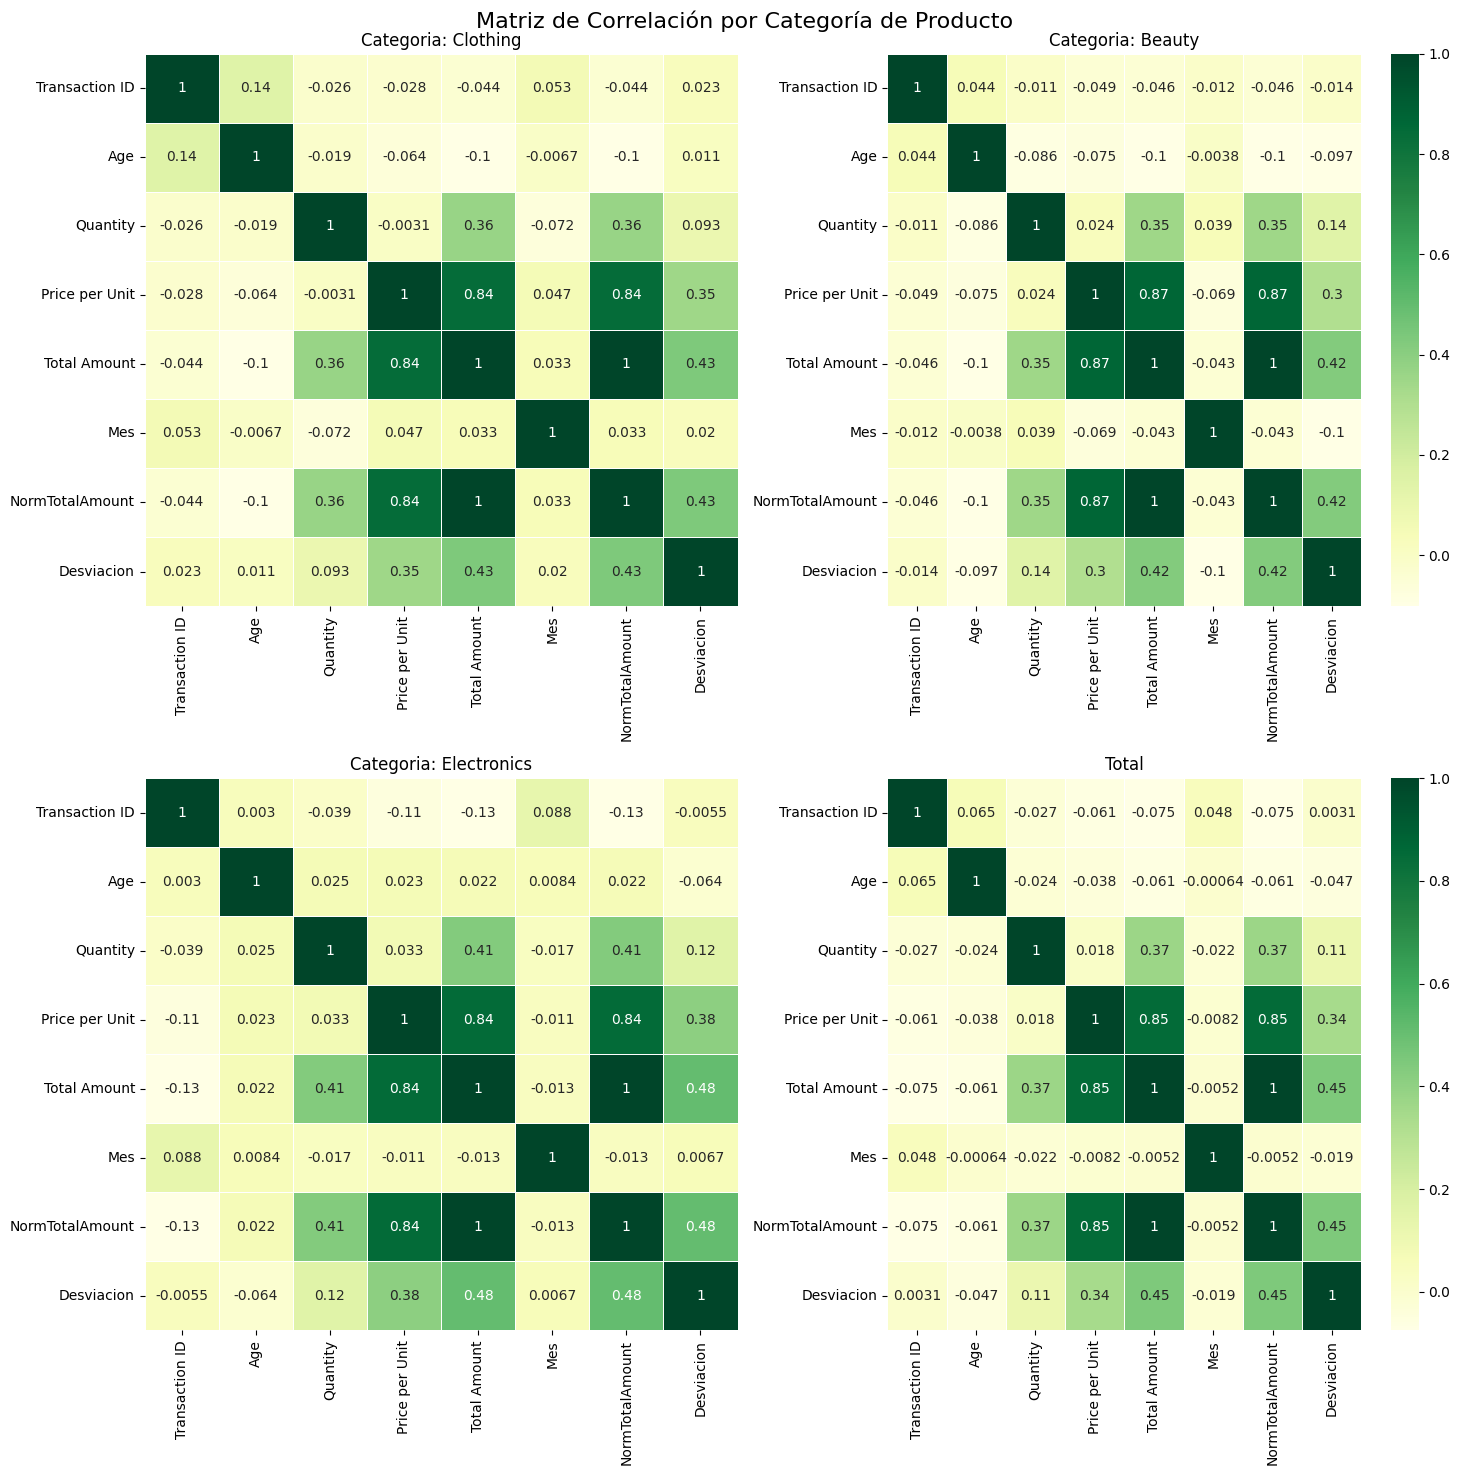

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
fig.suptitle('Matriz de Correlación por Categoría de Producto', fontsize=16)

sns.heatmap(Clothing.corr(numeric_only=True), annot=True, cmap='YlGn', linewidths=0.5, ax=axes[0,0], cbar=False)
sns.heatmap(Beauty.corr(numeric_only=True), annot=True, cmap='YlGn', linewidths=0.5, ax=axes[0,1])
sns.heatmap(Electronics.corr(numeric_only=True), annot=True, cmap='YlGn', linewidths=0.5, ax=axes[1,0], cbar=False)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlGn', linewidths=0.5, ax=axes[1,1])
axes[0,0].set_title('Categoria: Clothing')
axes[0,1].set_title('Categoria: Beauty')
axes[1,0].set_title('Categoria: Electronics')
axes[1,1].set_title('Total')



plt.tight_layout()
plt.show()

---
* No se observan correlaciones muy diferentes al separar componentes por categoria comprada
---

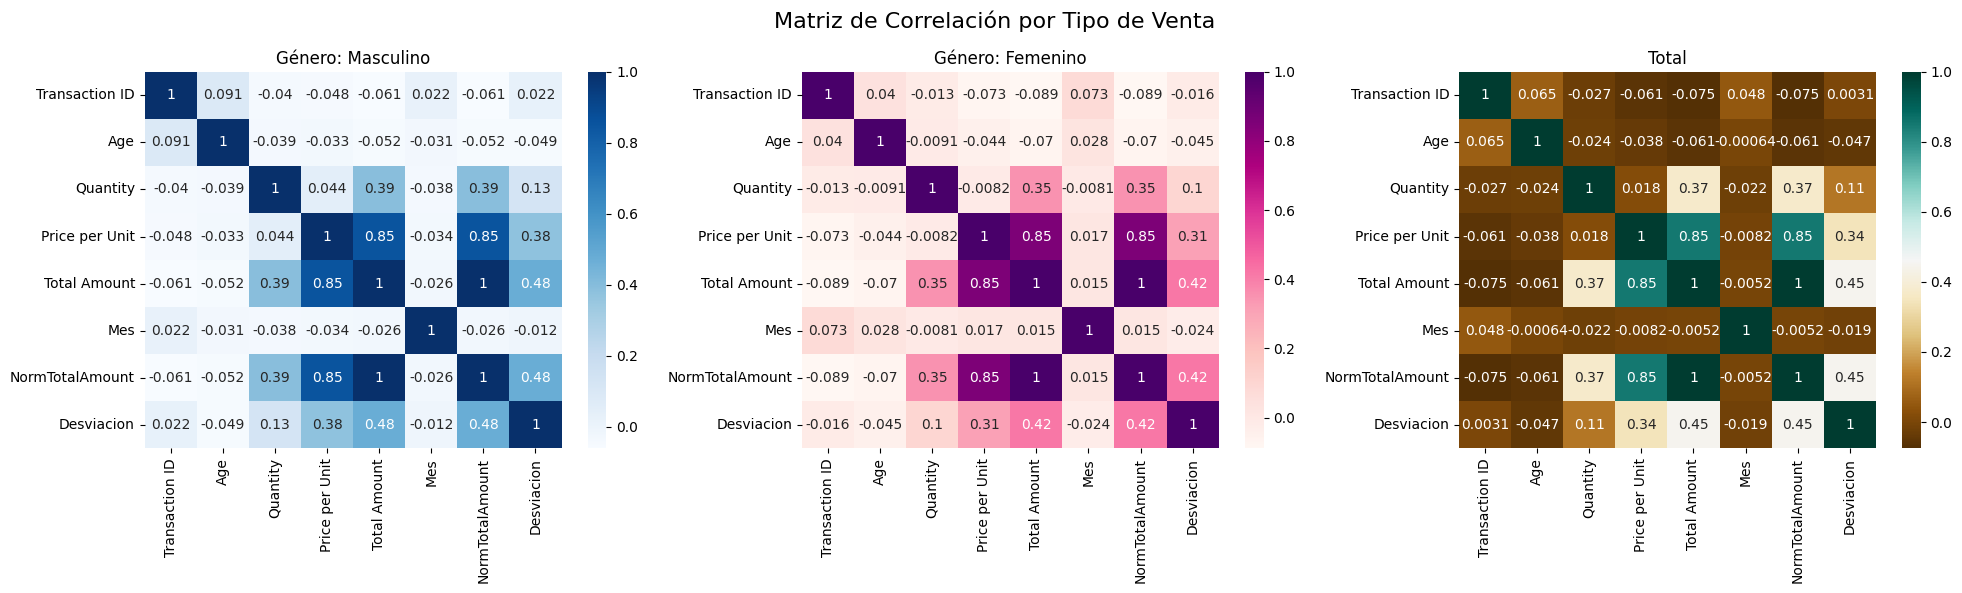

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Matriz de Correlación por Tipo de Venta', fontsize=16)

sns.heatmap(Male.corr(numeric_only=True), annot=True, cmap='Blues', ax=axes[0])
sns.heatmap(Female.corr(numeric_only=True), annot=True, cmap='RdPu', ax=axes[1])
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='BrBG', ax=axes[2])
axes[0].set_title('Género: Masculino')
axes[1].set_title('Género: Femenino')
axes[2].set_title('Total')




plt.tight_layout()
plt.show()

---
* No se observan diferencias por Sexo dentro del dataset

---


## Generar un Tag en GitHub
* Generar un Tag en GitHub: Después de completar el análisis y las visualizaciones, sube los cambios a una nueva rama en tu repositorio de GitHub, genera un Pull Request (PR) para revisión y finalmente crea un tag para esta versión del proyecto.

## Realizar una Presentación: 
Prepara una presentación en slides que resuma tu análisis y visualizaciones. 
La presentación debe incluir:
* Introducción y objetivos del proyecto.
* Descripción del conjunto de datos.
* Principales análisis y hallazgos.
* Visualizaciones clave con explicación.
* Conclusiones y recomendaciones.

Utiliza herramientas como PowerPoint, Google Slides o cualquier otra aplicación de presentación.

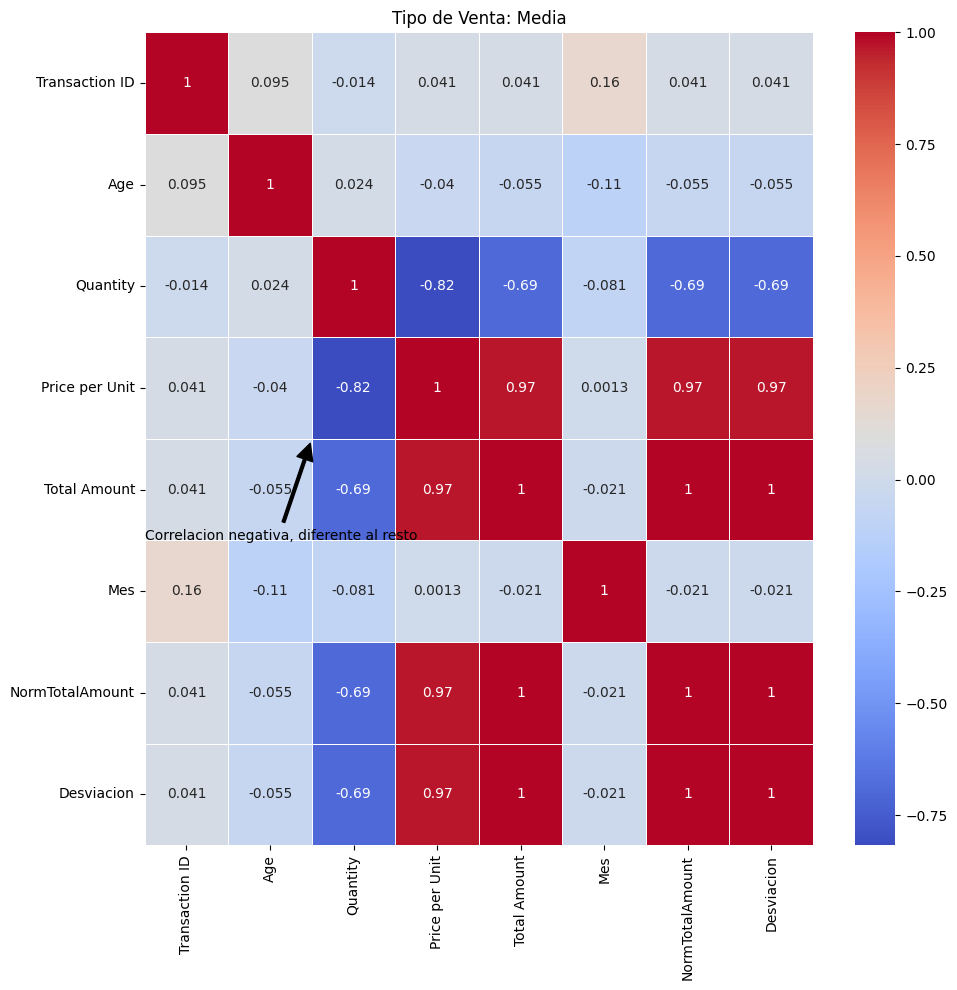

In [ ]:
#PARA COMPLETAR LOS REQUISITOS, VAMOS A COLOCAR UNA ANOTACION EN EL GRAFICO CON UNA FLECHA APUNTANDO A LA CELDA QUE ANTERIORMENTE DESTAQUE
fig, axes = plt.subplots(figsize=(10, 10))

sns.heatmap(Media.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)
axes.annotate('Correlacion negativa, diferente al resto', xy=(2, 4), xytext=(0, 5),arrowprops=dict(facecolor='black', shrink=0.05, width=2))


axes.set_title('Tipo de Venta: Media')

plt.tight_layout()
plt.show()